# Image dataset

Let's start with building a Torch Dataset of images. You'll use it to explore the data and, later, to feed it into a model.

In [2]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

# Compose transformations
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

# Create Dataset using ImageFolder
dataset_train = ImageFolder(
    "dataset/clouds/clouds_train",
    transform=train_transforms,
)


# Data augmentation

Data augmentation is used for training almost all image-based models. Understanding what it does (and what it doesn't) is crucial to using it effectively.

Which of the following statements correctly describe data augmentation?

- Using data augmentation allows the model to learn from more examples
- Using data augmentation increases the diversity of the training data
- Data augmentation makes the model more robust to variations and distortions commonly found in real-world images
- Data augmentation reduces the risk of overfitting as the model learns to ignore the random transformations

# Data augmentation in PyTorch

Let's include data augmentation in your Dataset and inspect some images visually to make sure the desired transformations are applied.

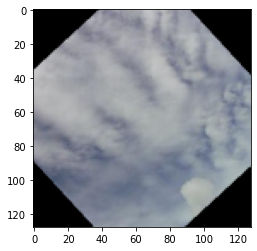

In [3]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

train_transforms = transforms.Compose([
    # Add horizontal flip and rotation
    transforms.RandomHorizontalFlip(), # Data augmentation using horizontal flip
    transforms.RandomRotation(45),  # Data augmentation using rotation to image
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

dataset_train = ImageFolder(
  "dataset/clouds/clouds_train",
  transform=train_transforms,
)

dataloader_train = DataLoader(
  dataset_train, shuffle=True, batch_size=1
)

image, label = next(iter(dataloader_train))
# Reshape the image tensor
image = image.squeeze().permute(1, 2, 0)
# Display the image
plt.imshow(image)
plt.show()

# The convolutional layer

Convolutional layers are the basic building block of most computer vision architectures. Understanding why they're used and how they work is crucial for building image-processing neural networks.

Which of the following statements are true about convolutional layers?

- Convolutional layers preserve spatial information between their inputs and outputs.
- Adding zero-padding around the convolutional layer's input ensures that the pixels at the border receive as much attention as those located elsewhere in the feature map.
- Convolutional layers in general use fewer parameters than linear layers.

# Building convolutional networks

You are on a team building a weather forecasting system. As part of the system, cameras will be installed at various locations to take pictures of the sky. Your task is to build a model to classify different cloud types in these pictures, which will help spot approaching weather fronts.

You decide to build a convolutional image classifier. The model will consist of two parts:

- A feature extractor that learns a vector of features from the input image,
- A classifier that predicts the image's class based on the learned features.

In [5]:
from torch import nn
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Define feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
        )
        # Define classifier
        self.classifier = nn.Linear(64*16*16, num_classes)
    
    def forward(self, x):  
        # Pass input through feature extractor and classifier
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

# Choosing augmentations

You are building a model to recognize different flower species. You consider three augmentations to use: color shift, rotation, and texture change. The graphic below shows the examples of these three augmentations.

<center><img src="images/02.01.png"  style="width: 400px, height: 300px;"/></center>

- Only rotation (The flower is still the same species when it's rotated, so this augmentation will not introduce noise in training labels; rather, it will increase the diversity of the training samples!)
- NOT color shift, because same type of flower with different color may appear as different species
- NOT texture change, due to the same reason as color shift

# Dataset with augmentations

You have already built the image dataset from cloud pictures and the convolutional model to classify different cloud types. Before you train it, let's adapt the dataset by adding the augmentations that could improve the model's cloud classification performance.

The code to set up the Dataset and DataLoader is already prepared for you and should look familiar. Your task is to define the composition of transforms that will be applied to the input images as they are loaded.

Note that before you were resizing images to 128 by 128 to display them nicely, but now you will use smaller ones to speed up training. As you will see later, 64 by 64 will be large enough for the model to learn.

In [6]:
# Define transforms
train_transforms = transforms.Compose([ # NO Data augmentation for test data
    transforms.RandomHorizontalFlip(), # Data augmentation using horizontal flip
    transforms.RandomRotation(45),  # Data augmentation using rotation to image
    transforms.RandomAutocontrast(), # Data augmentation using contrast to image
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

dataset_train = ImageFolder(
  "dataset/clouds/clouds_train",
  transform=train_transforms,
)
dataloader_train = DataLoader(
  dataset_train, shuffle=True, batch_size=16
)

# Image classifier training loop

It's time to train the image classifier! You will use the Net you defined earlier and train it to distinguish between seven cloud types.

To define the loss and optimizer, you will need to use functions from torch.nn and torch.optim, imported for you as nn and optim, respectively. You don't need to change anything in the training loop itself: it's exactly like the ones you wrote before, with some additional logic to print the loss during training.

In [15]:
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, num_classes):
        super(Net, self).__init__()
        
        # Feature extractor layers
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ELU(alpha=1.0),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ELU(alpha=1.0),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten()
        )
        
        # Classifier layers
        self.classifier = nn.Linear(65536, num_classes)  # Adjust the in_features based on the output shape of Flatten

    def forward(self, x):
        # Forward pass through the network
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

# Instantiate the network with num_classes=7
net = Net(num_classes=7)

# Print the network architecture
print(net)


Net(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ELU(alpha=1.0)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ELU(alpha=1.0)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Linear(in_features=65536, out_features=7, bias=True)
)


In [16]:
import torch.optim as optim
# Define the model
net = Net(num_classes = 7)
# Define the loss function
criterion = nn.CrossEntropyLoss()
# Define the optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

for epoch in range(3):
    running_loss = 0.0
    # Iterate over training batches
    for images, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(dataloader_train)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 3.1281
Epoch 2, Loss: 1.6174
Epoch 3, Loss: 1.5240


# Multi-class model evaluation

Let's evaluate our cloud classifier with precision and recall to see how well it can classify the seven cloud types. In this multi-class classification task it is important how you average the scores over classes. Recall that there four approaches:

- Not averaging, and analyzing the results per class;
- Micro-averaging, ignoring the classes and computing the metrics globally;
- Macro-averaging, computing metrics per class and averaging them;
- Weighted-averaging, just like macro but with the average weighted by class size.

In [21]:

test_transforms = transforms.Compose([
    transforms.RandomRotation(45),  # Data augmentation using rotation to image
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])


dataset_test = ImageFolder(
  "dataset/clouds/clouds_train",
  transform=test_transforms,
)
dataloader_test = DataLoader(
  dataset_test, shuffle=True, batch_size=16
)

In [24]:
from torchmetrics import Precision, Recall
# Define metrics
metric_precision = Precision(task="multiclass", num_classes=7, average='micro')
metric_recall = Recall(task="multiclass", num_classes=7, average='micro')

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
        metric_recall(preds, labels)

precision = metric_precision.compute()
recall = metric_recall.compute()
print(f"Precision: {precision}")
print(f"Recall: {recall}")

Precision: 0.49789029359817505
Recall: 0.49789029359817505


In [23]:


from torchmetrics import Precision, Recall
# Define metrics
metric_precision = Precision(task="multiclass", num_classes=7, average='macro')
metric_recall = Recall(task="multiclass", num_classes=7, average='macro')

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
        metric_recall(preds, labels)

precision = metric_precision.compute()
recall = metric_recall.compute()
print(f"Precision: {precision}")
print(f"Recall: {recall}")

Precision: 0.5647061467170715
Recall: 0.42637723684310913


# Analyzing metrics per class

While aggregated metrics are useful indicators of the model's performance, it is often informative to look at the metrics per class. This could reveal classes for which the model underperforms.

In this exercise, you will run the evaluation loop again to get our cloud classifier's precision, but this time per-class. Then, you will map these score to the class names to interpret them. 

In [26]:
# Define precision metric
metric_precision = Precision(task="multiclass", num_classes=7, average=None)

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
precision = metric_precision.compute()

# Get precision per class
precision_per_class = {k: precision[v].item() for k, v in dataset_test.class_to_idx.items()}

print(precision_per_class)

{'cirriform clouds': 0.3030303120613098, 'clear sky': 0.8139534592628479, 'cumulonimbus clouds': 1.0, 'cumulus clouds': 0.5799999833106995, 'high cumuliform clouds': 0.41754385828971863, 'stratiform clouds': 0.800000011920929, 'stratocumulus clouds': 0.42424243688583374}
